In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import accuracy_score

In [2]:
df= pd.read_csv("cleaned_heart_data.csv", encoding="latin1")
df.head()

,Age,Gender,Blood Pressure,Cholesterol Level (mg/dL),Heart Rate (bpm),Chest Pain Type,Exercise Frequency,Do you smoke?,Family history of heart disease?,Do you have heart disease?
0,25,Male,100.0,172.0,92.0,Asymptomatic,Regular,No,Yes,No
1,29,Female,105.0,168.2,94.6,Typical Angina,Sometimes,No,No,No
2,33,Male,109.7,183.9,96.2,Atypical Angina,Never,No,No,No
3,37,Female,114.1,179.1,96.1,Non-anginal Pain,Sometimes,No,Yes,No
4,41,Male,117.9,194.0,94.2,Asymptomatic,Sometimes,No,No,No


In [3]:
df.shape

(1968, 10)

In [4]:
categorical_cols = df.select_dtypes(include='object').columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

### Label Encoder

In [5]:
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1968 entries, 0 to 1967
Data columns (total 10 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               1968 non-null   int64  
 1   Gender                            1968 non-null   int64  
 2   Blood Pressure                    1968 non-null   float64
 3   Cholesterol Level (mg/dL)         1968 non-null   float64
 4   Heart Rate (bpm)                  1968 non-null   float64
 5   Chest Pain Type                   1968 non-null   int64  
 6   Exercise Frequency                1968 non-null   int64  
 7   Do you smoke?                     1968 non-null   int64  
 8   Family history of heart disease?  1968 non-null   int64  
 9   Do you have heart disease?        1968 non-null   int64  
dtypes: float64(3), int64(7)
memory usage: 153.9 KB


In [6]:
df.head()

,Age,Gender,Blood Pressure,Cholesterol Level (mg/dL),Heart Rate (bpm),Chest Pain Type,Exercise Frequency,Do you smoke?,Family history of heart disease?,Do you have heart disease?
0,25,1,100.0,172.0,92.0,0,1,0,1,0
1,29,0,105.0,168.2,94.6,3,2,0,0,0
2,33,1,109.7,183.9,96.2,1,0,0,0,0
3,37,0,114.1,179.1,96.1,2,2,0,1,0
4,41,1,117.9,194.0,94.2,0,2,0,0,0


### Visualize

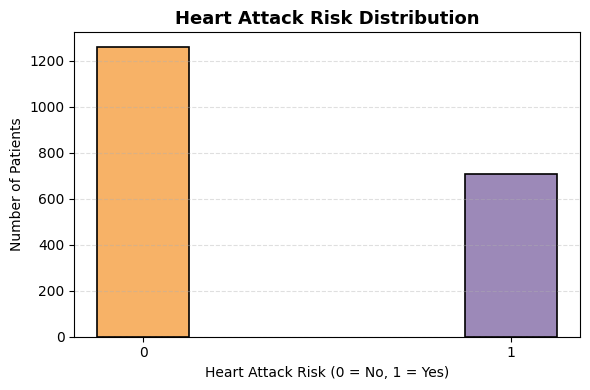

In [7]:
counts = df['Do you have heart disease?'].value_counts()

plt.figure(figsize=(6,4))
plt.bar(counts.index.astype(str), counts.values, 
        width=0.25,  # Thinner bars
        color=['#F7B267', '#9C89B8'],  # Soft peach = No risk, Lavender = Risk
        edgecolor='black', linewidth=1.2)

plt.title("Heart Attack Risk Distribution", fontsize=13, fontweight='bold')
plt.xlabel("Heart Attack Risk (0 = No, 1 = Yes)")
plt.ylabel("Number of Patients")
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


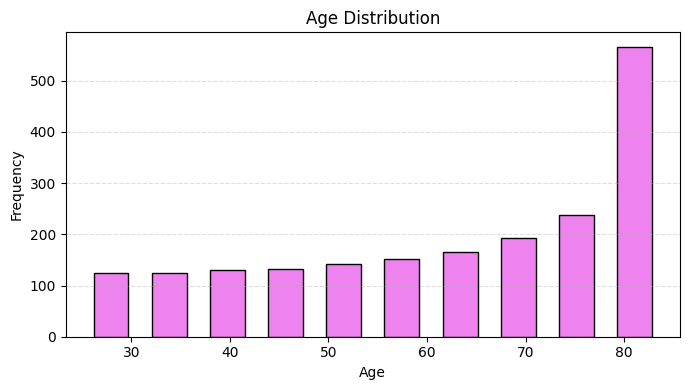

In [ ]:
plt.figure(figsize=(7,4))
plt.hist(
    df['Age'],
    bins=10,
    rwidth=0.6,          # more gap between bars
    color='violet',
    edgecolor='black'
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


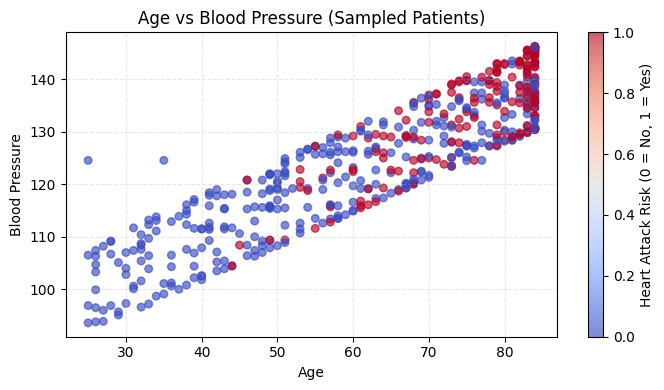

In [ ]:
# Take a small random sample
sample_df = df.sample(500, random_state=42)


plt.figure(figsize=(7,4))

plt.scatter(
    sample_df['Age'],
    sample_df['Blood Pressure'],
    c=sample_df['Do you have heart disease?'],   # color by risk
    cmap='coolwarm',                    # beautiful contrast colors
    alpha=0.65,
    s=30
)

plt.title("Age vs Blood Pressure (Sampled Patients)")
plt.xlabel("Age")
plt.ylabel("Blood Pressure")
plt.colorbar(label="Heart Attack Risk (0 = No, 1 = Yes)")
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


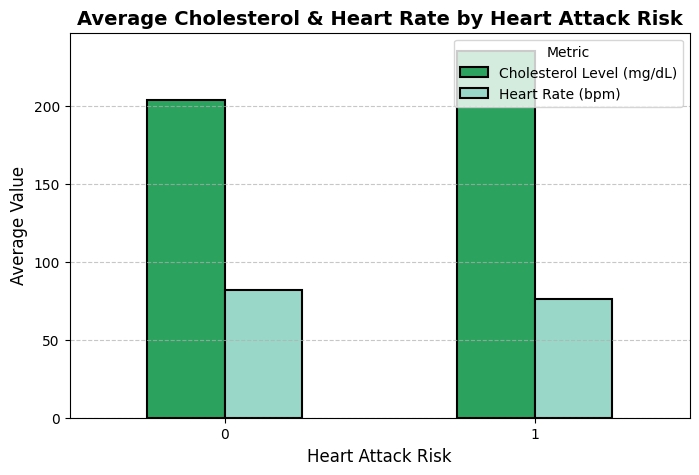

In [10]:
# Group by Heart Attack Risk
grouped = df.groupby('Do you have heart disease?')[['Cholesterol Level (mg/dL)', 'Heart Rate (bpm)']].mean()

# Plot grouped bar chart with vibrant greens
ax = grouped.plot(
    kind='bar',
    figsize=(8,5),
    color=['#2ca25f', '#99d8c9'],  # vibrant green shades
    edgecolor='black',              # black border
    linewidth=1.5
)

plt.title("Average Cholesterol & Heart Rate by Heart Attack Risk", fontsize=14, fontweight='bold')
plt.ylabel("Average Value", fontsize=12)
plt.xlabel("Heart Attack Risk", fontsize=12)
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


### Splitting

In [11]:
X = df.drop("Do you have heart disease?", axis=1)
y = df["Do you have heart disease?"]


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)


### Scailing

In [13]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [14]:
X_train.shape

(1476, 9)

In [15]:
X_test.shape

(492, 9)

## 1. Logistic Regression

In [16]:
model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [17]:
y_pred = model.predict(X_test)

In [18]:
mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error:", mae)


Mean Absolute Error: 0.05894308943089431


In [19]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[307  13]
 [ 16 156]]


307 + 13 + 16 + 156 = 492 --> testing data

In [20]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9410569105691057


In [21]:
# Actual vs Predicted Results
results = pd.DataFrame({
    "Actual Heart Attack Risk": y_test.values,
    "Predicted Heart Attack Risk": y_pred
})

print(results.head())


   Actual Heart Attack Risk  Predicted Heart Attack Risk
0                         0                            0
1                         0                            0
2                         0                            0
3                         0                            1
4                         0                            0


## 2. KNN

In [22]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [23]:
knn_pred = knn_model.predict(X_test)

In [24]:
knn_mae = mean_absolute_error(y_test, knn_pred)
knn_acc = accuracy_score(y_test, knn_pred)

print("KNN MAE:", knn_mae)
print("KNN Accuracy:", knn_acc)


KNN MAE: 0.016260162601626018
KNN Accuracy: 0.983739837398374


In [25]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[307  13]
 [ 16 156]]


In [26]:
knn_results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": knn_pred
})

knn_results.head()


,Actual,Predicted
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0


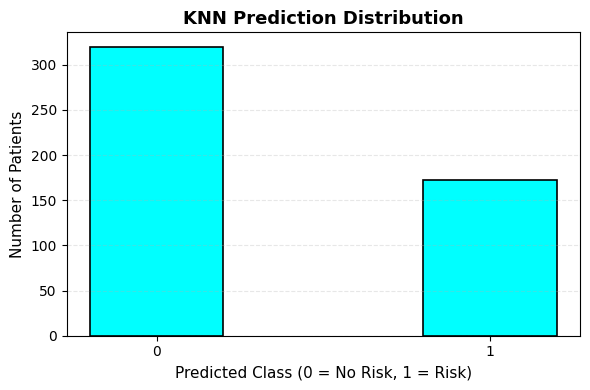

In [27]:
knn_counts = pd.Series(knn_pred).value_counts().sort_index()

plt.figure(figsize=(6,4))
plt.bar(
    knn_counts.index.astype(str),
    knn_counts.values,
    width=0.4,              # good gap between bars
    color='cyan',           # cyan color
    edgecolor='black',
    linewidth=1.2
)

plt.title("KNN Prediction Distribution", fontsize=13, fontweight='bold')
plt.xlabel("Predicted Class (0 = No Risk, 1 = Risk)", fontsize=11)
plt.ylabel("Number of Patients", fontsize=11)

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


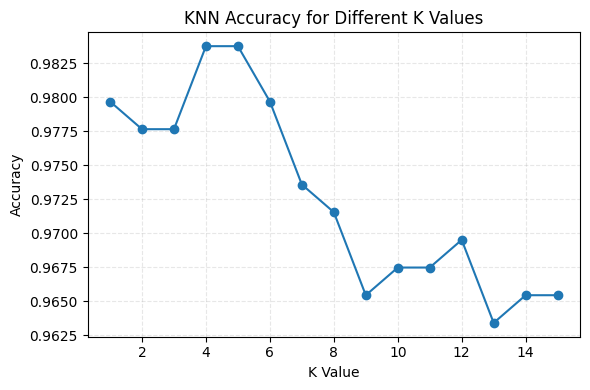

In [28]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

k_values = range(1, 16)
acc_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    preds = knn.predict(X_test)
    acc_scores.append(accuracy_score(y_test, preds))

plt.figure(figsize=(6,4))
plt.plot(k_values, acc_scores, marker='o')
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy for Different K Values")
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


## 3. Random Forest

In [29]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf_model.fit(X_train, y_train)



,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [30]:
rf_pred = rf_model.predict(X_test)

In [31]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_acc = accuracy_score(y_test, rf_pred)

print("Random Forest MAE:", rf_mae)
print("Random Forest Accuracy:", rf_acc)


Random Forest MAE: 0.0
Random Forest Accuracy: 1.0


In [32]:
cm = confusion_matrix(y_test, rf_pred)

print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[320   0]
 [  0 172]]


In [33]:
rf_results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": rf_pred
})

rf_results.head()


,Actual,Predicted
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0


## All 3 Comparision

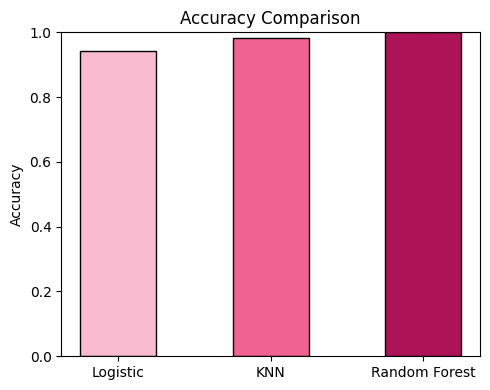

In [34]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score

log_acc = accuracy_score(y_test, model.predict(X_test))
knn_acc = accuracy_score(y_test, knn_model.predict(X_test))
rf_acc  = accuracy_score(y_test, rf_model.predict(X_test))

models = ['Logistic', 'KNN', 'Random Forest']
acc = np.array([log_acc, knn_acc, rf_acc])

order = np.argsort(acc)
colors = ['#f8bbd0', '#f06292', '#ad1457']   # light → medium → dark pink

bar_colors = [None]*3
for i, idx in enumerate(order):
    bar_colors[idx] = colors[i]

plt.figure(figsize=(5,4))
plt.bar(models, acc, color=bar_colors, edgecolor='black', width=0.5)
plt.ylim(0,1)
plt.title("Accuracy Comparison")
plt.ylabel("Accuracy")
plt.tight_layout()
plt.show()


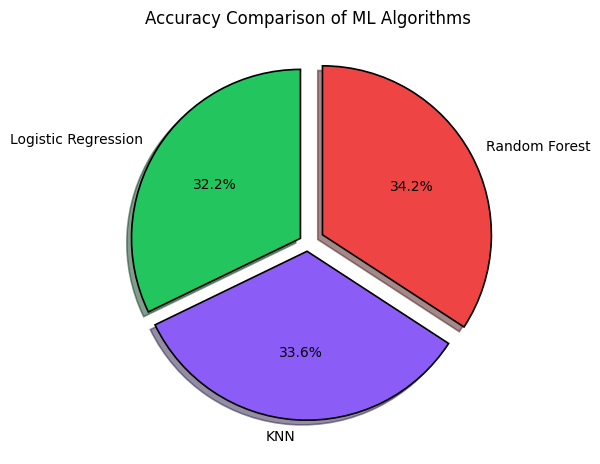

In [35]:
import matplotlib.pyplot as plt

labels = ['Logistic Regression', 'KNN', 'Random Forest']
sizes = [accuracy, knn_acc, rf_acc]
colors = ['#22C55E', '#8B5CF6', '#EF4444']

plt.figure(figsize=(6,6))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%',
        startangle=90, explode=(0.05,0.05,0.1), shadow=True,
        wedgeprops={'edgecolor':'black', 'linewidth':1.2})
plt.title("Accuracy Comparison of ML Algorithms")
plt.tight_layout()
plt.show()


### Overall, Random Forest Classifier gave the best result.